In [ ]:
import pandas as pd
sales = pd.read_csv("D:\old dataset\sales_train_validation.csv")
cal = pd.read_csv('D:\old dataset\calendar.csv')
sell = pd.read_csv('D:\old dataset\sell_prices.csv')


In [ ]:
all = pd.melt(
    sales,
    id_vars=['item_id','store_id','dept_id','cat_id','state_id'],
    var_name='day',
    value_name='sales'
)

# =========================
# 3. MERGE WITH CALENDAR
# =========================

all = all.merge(cal, left_on='day', right_on='d')

# =========================
# 4. CONVERT DATE
# =========================

all['date'] = pd.to_datetime(all)

# =========================
# 5. SORT DATA
# =========================

all = all.sort_values(['item_id','store_id','date'])

# =========================
# 6. SPLIT DATA
# =========================

train= all[all['date'].dt.year < 2016].copy()
test_2016_df = all[all['date'].dt.year == 2016].copy()

# =========================
# 7. SAVE OUTPUT (OPTIONAL)
# =========================

train.to_csv("data/train_before_2016.csv", index=False)
test_2016_df.to_csv("data/test_2016.csv", index=False)





In [ ]:
train =pd.read_csv("D:\old dataset\\train test\\train.csv")

In [ ]:
def reduce_mem(train):
    for col in train.columns:
        if train[col].dtype == 'int64':
            train[col] = train[col].astype('int32')
        elif train[col].dtype == 'float64':
            train[col] = train[col].astype('float32')
    return train

df = reduce_mem(train)

In [26]:
train['day'] = train['day'].str.replace('d_', '', regex=False)
train['day'] = train['day'].astype('int32')

In [38]:
train = train[train['day'] > 1100]

In [23]:
train.drop(columns=['d'], inplace=True)

In [47]:
price_map = sell.set_index(['store_id','item_id','wm_yr_wk'])['sell_price']

train['sell_price'] = train.set_index(['store_id','item_id','wm_yr_wk']).index.map(price_map)

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_21640\2112535156.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['sell_price'] = train.set_index(['store_id','item_id','wm_yr_wk']).index.map(price_map)


In [52]:
train.head()

,item_id,store_id,dept_id,cat_id,state_id,day,sales,date,wm_yr_wk,weekday,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
33539000,HOBBIES_1_001,CA_1,HOBBIES_1,HOBBIES,CA,1101,0,2014-02-02,11401,Sunday,...,2,2014,SuperBowl,Sporting,NaN,NaN,1,0,1,8.26
33539001,HOBBIES_1_002,CA_1,HOBBIES_1,HOBBIES,CA,1101,0,2014-02-02,11401,Sunday,...,2,2014,SuperBowl,Sporting,NaN,NaN,1,0,1,3.97
33539002,HOBBIES_1_003,CA_1,HOBBIES_1,HOBBIES,CA,1101,0,2014-02-02,11401,Sunday,...,2,2014,SuperBowl,Sporting,NaN,NaN,1,0,1,2.97
33539003,HOBBIES_1_004,CA_1,HOBBIES_1,HOBBIES,CA,1101,2,2014-02-02,11401,Sunday,...,2,2014,SuperBowl,Sporting,NaN,NaN,1,0,1,4.64
33539004,HOBBIES_1_005,CA_1,HOBBIES_1,HOBBIES,CA,1101,1,2014-02-02,11401,Sunday,...,2,2014,SuperBowl,Sporting,NaN,NaN,1,0,1,3.08


In [ ]:
train.to_csv('train.csv')


<Axes: xlabel='month'>

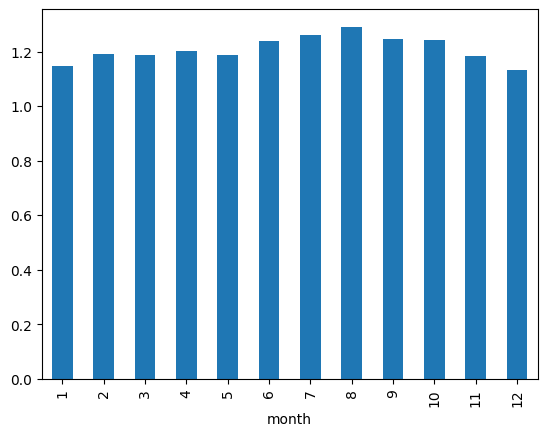

In [62]:
train.groupby('month')['sales'].mean().plot(kind='bar')

<Axes: xlabel='store_id'>

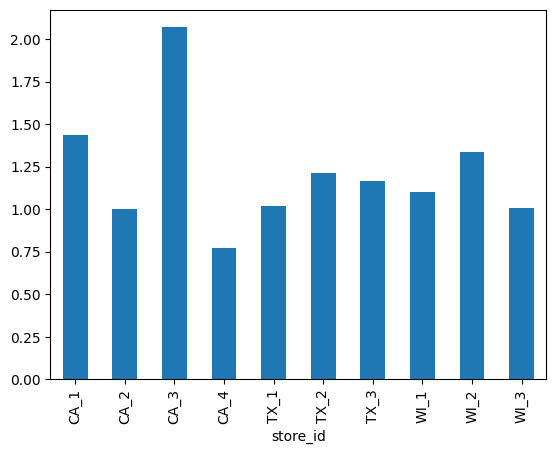

In [61]:
train.groupby('store_id')['sales'].mean().plot(kind='bar')

<Axes: xlabel='weekday'>

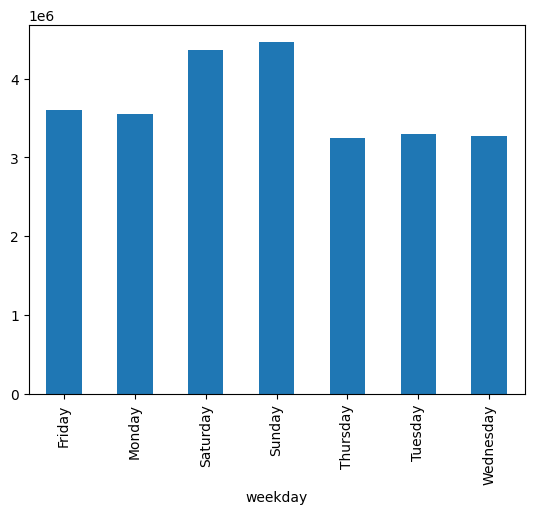

In [63]:
train.groupby('weekday')['sales'].sum().plot(kind='bar')

<Axes: xlabel='store_id'>

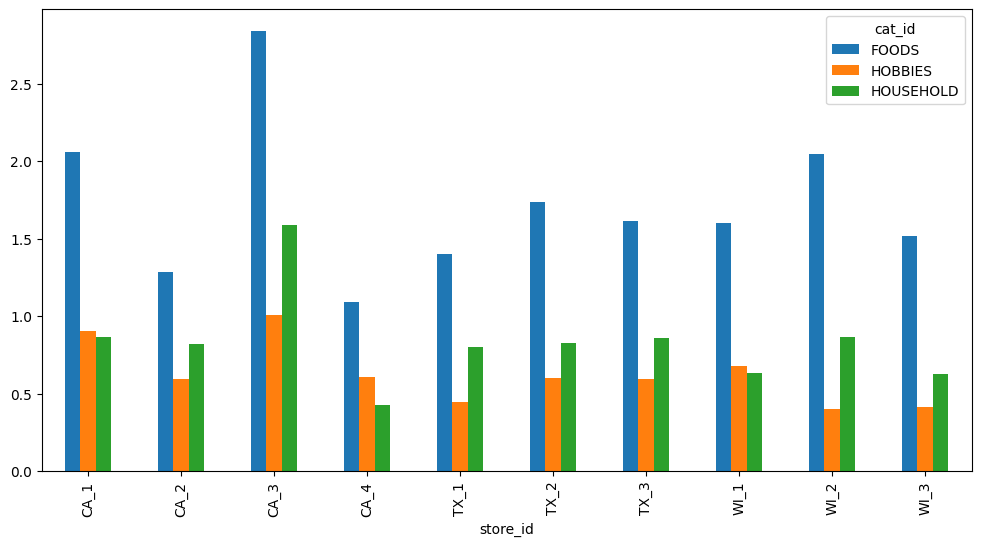

In [64]:
train.groupby(['store_id','cat_id'])['sales'].mean().unstack().plot(kind='bar', figsize=(12,6))